
##Argimiro Arratia @2023-2025 Computational Finance
##Pylab: ML Models: NNET, GaussProc, and LSTM modeling of PRICE or RETURN
###  Testing Shiller&Campbell hyp: PE10 --> S&P500 (Price2Earnings)
###### http://computationalfinance.lsi.upc.edu


SAME AS PROBLEM 2

###Libraries for Neural Networks (MLPRegressor) and Gaussian Process (GaussianProcessRegressor)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn import metrics
from tabulate import tabulate ##for printing pretty tables

In [ ]:
##Libraries for LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

####Evaluation metrics
see https://scikit-learn.org/stable/modules/model_evaluation.html

We use Normalize Residual Mean Square Error (NRMSE) (similar to R^2), and from this the percentage of outperforming direct sample mean (sample expected value)

In [ ]:
from sklearn.metrics import mean_squared_error

def nrmse(y_actual, y_predicted):
  return np.sqrt(mean_squared_error(y_actual, y_predicted)/np.mean(np.sum((y_actual-np.mean(y_actual))**2)))
## np.mean(y_actual.shift(1).dropna())
##Note: function mean_squared_error takes both arguments as arrays, so fails when given (array, mean (a number)), so must write this from scratch

def pcorrect(y_actual, y_predicted):
  return (1-nrmse(y_actual, y_predicted))*100


In [ ]:
# fix random seed for reproducibility
np.random.seed(7)
##tf.random.set_seed(7)

<Axes: xlabel='Date'>

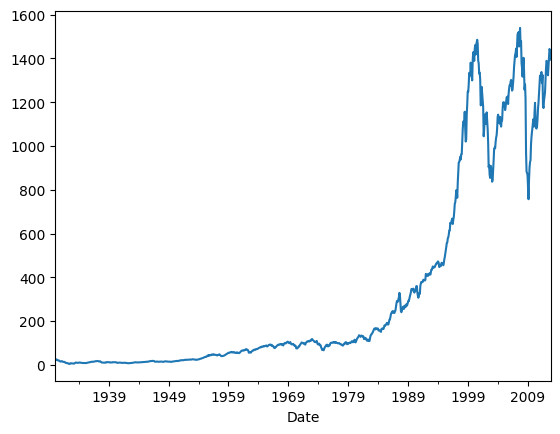

In [ ]:
# Read data (in Colab click on Archives icon at left panel and place the data file .csv)
sp500 = pd.read_csv('SP500_shiller.csv', index_col=0, parse_dates=True)
# Select data from 1925 to 2012
data = sp500.loc['1930-01-01':'2012-12-31']
data['SP500'].plot()

In [ ]:
data.head()

,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,P/E10
Date,,,,,,,,,
1930-01-01,21.71,0.97,1.56,17.1,3.29,297.96,13.32,21.37,22.31
1930-02-01,23.07,0.97,1.50,17.0,3.29,318.49,13.41,20.75,23.70
1930-03-01,23.94,0.97,1.45,16.9,3.30,332.46,13.51,20.14,24.59
1930-04-01,25.46,0.97,1.40,17.0,3.30,351.49,13.44,19.29,25.84
1930-05-01,23.94,0.97,1.34,16.9,3.31,332.46,13.53,18.65,24.31


In [ ]:
# Frequency of sampling
tau = 1 #data is monthly. Try tau=12 (year), tau=3 (quarterly)

Price is non stationary (but good results) --> not mean anything. Not use this. Use Returns (but hardest to model). Or a classification model. Results are not that important, it's about the discussion. It's important to do a good feature selection, pre-processing, hyperparamerter tuning. 

In [ ]:
# Option 1. Target and Feature as plain Price (Execute in all cases)
target = data['SP500']
sp500PE = data['P/E10'].dropna() ##feature:P/E MA(10)
sp500PE.head()

,P/E10
Date,
1930-01-01,22.31
1930-02-01,23.70
1930-03-01,24.59
1930-04-01,25.84
1930-05-01,24.31


In [ ]:
# Option 2. Target and Feature as Returns (omit this part if want to work with price)
sp500PE = np.log(sp500PE).diff(tau)
target = np.log(target).diff(tau)
# try non-center (above) /center target (below)
target = target - target.mean() ##Center the target

In [ ]:
# Model Inputs:
# Define matrix of features (each column is a feature)
# Features: lags 1,2,3 with (or w/o) PE10 and lags 1,2
feat = pd.concat([target.shift(1), target.shift(2), target.shift(3),
                  sp500PE.shift(1), sp500PE.shift(2),
                  # add other features here,
                  target], axis=1)
feat.columns = ['lag.1', 'lag.2', 'lag.3',
                'PE10.1', 'PE10.2',
                # names of other features,
                'TARGET']
feat = feat.dropna()
feat.head()

,lag.1,lag.2,lag.3,PE10.1,PE10.2,TARGET
Date,,,,,,
1930-05-01,0.057355,0.032814,0.056557,0.049584,0.036865,-0.065761
1930-06-01,-0.065761,0.057355,0.032814,-0.061036,0.049584,-0.110771
1930-07-01,-0.110771,-0.065761,0.057355,-0.105772,-0.061036,-0.025810
1930-08-01,-0.025810,-0.110771,-0.065761,-0.014740,-0.105772,-0.017107
1930-09-01,-0.017107,-0.025810,-0.110771,-0.011669,-0.014740,-0.004684


We have to keep in mind data leakage --> 1. cronologicaly splitting (fine for homework) or 2. a time series split (more advanced)

In [ ]:
# Divide data into training (75%) and testing (25%).
T = len(feat)
p = 0.75
trainindex = round(p*T)

# process class sets as data frames
training = feat.iloc[:trainindex, :]
testing = feat.iloc[trainindex:, :]

display(training.tail())
display(testing.head())

,lag.1,lag.2,lag.3,PE10.1,PE10.2,TARGET
Date,,,,,,
1991-12-01,-0.006688,-0.005030,-0.009869,-0.003275,-0.000545,0.002486
1992-01-01,0.002486,-0.006688,-0.005030,0.008168,-0.003275,0.064355
1992-02-01,0.064355,0.002486,-0.006688,0.069643,0.008168,-0.012699
1992-03-01,-0.012699,0.064355,0.002486,-0.009657,0.069643,-0.016888
1992-04-01,-0.016888,-0.012699,0.064355,-0.015440,-0.009657,-0.004081


,lag.1,lag.2,lag.3,PE10.1,PE10.2,TARGET
Date,,,,,,
1992-05-01,-0.004081,-0.016888,-0.012699,0.001037,-0.015440,0.013797
1992-06-01,0.013797,-0.004081,-0.016888,0.018481,0.001037,-0.020095
1992-07-01,-0.020095,0.013797,-0.004081,-0.017445,0.018481,0.012267
1992-08-01,0.012267,-0.020095,0.013797,0.015409,-0.017445,0.002712
1992-09-01,0.002712,0.012267,-0.020095,0.005084,0.015409,-0.002888


## Model 1 & 2: NNET (multilayer and one layer)
Check documentation: [MLPRegressor sklearn](https://scikit-learn.org/1.6/modules/generated/sklearn.neural_network.MLPRegressor.html)

Careful NOT to shuffle data: You are working with time dependent data!

shuffle = false bc of time series

In [ ]:
# Using multiple hidden layer with c(size, size, ...) many nodes
size = 300
decay = 10 ** -2
nnet_fit1 = MLPRegressor(
    hidden_layer_sizes=(size, size, size),
    max_iter=100000,
    activation= "relu",  #"logistic", # "tanh",
    shuffle=False, #ATTENTION with this parameter (check help manual)
    solver="adam", # "lbfgs", "sgd"
    alpha=decay
    )

In [ ]:
nnet_fit1.fit(training_features, training_target)

MLPRegressor(alpha=0.01, hidden_layer_sizes=(300, 300, 300), max_iter=100000,
             shuffle=False)

In [ ]:
# Build the predictor
testing_target = testing.iloc[:, :-1]
pred_nnet1 = nnet_fit1.predict(testing_target)

In [ ]:
# Alternative using nnet with ONE hidden layer with size many nodes
# Parameters to tune: size, weight decay (a regularization of type L2 in penalty funct that shrinks weights)
size = 2000
decay = 10 ** -2
nnet_fit2 = MLPRegressor(hidden_layer_sizes=(size),
                         activation="logistic", # "tanh", "relu"
                         shuffle=False,
                         solver="adam", # "lbfgs", "sgd"
                         max_iter=10000, alpha=decay
                         )


deep and narrow and generalize better but few layers is also fine

In [ ]:
nnet_fit2.fit(training_features, training_target)

MLPRegressor(activation='logistic', alpha=0.01, hidden_layer_sizes=2000,
             max_iter=10000, shuffle=False)

In [ ]:
# Build the predictor
testing_target = testing.iloc[:, :-1]
pred_nnet2 = nnet_fit2.predict(testing_target)

mention the grid search and that kind of stuff

## Model 3: GP
Check documentation: [GaussianProcessRegressor sklearn](https://scikit-learn.org/dev/modules/generated/sklearn.gaussian_process.GaussianProcessRegressor.html)

In [ ]:
# Gaussian process
gp_fit = GaussianProcessRegressor(
    kernel=RBF(), # Try other kernels (e.g. RBF, Matern, RationalQuadratic, or your own)
    alpha=0.003
)

In [ ]:
gp_fit.fit(training_features, training_target)

GaussianProcessRegressor(alpha=0.003, kernel=RBF(length_scale=1))

alpha 0.003 observation --> too small alpha leads to overfitting.

In [ ]:
# Build the predictor
pred_gp = gp_fit.predict(testing_target)

In [ ]:
testing_target = testing.iloc[:, -1]
testing_target.shift(1).dropna()

,TARGET
Date,
1992-06-01,0.013797
1992-07-01,-0.020095
1992-08-01,0.012267
1992-09-01,0.002712
1992-10-01,-0.002888
...,...
2012-08-01,0.022855
2012-09-01,0.027407
2012-10-01,0.023879


####Performance Evaluation and comparison among models

In [ ]:
##Evaluation of results pcorrect = 100*(1-NRMSE)
print(tabulate([['NnetMulti', pcorrect(pred_nnet1,testing_target)],
                ['NnetSingle', pcorrect(pred_nnet2,testing_target)],
                ['GP', pcorrect(pred_gp,testing_target)]],
                            headers=['Model','% outperform mean']))

Model         % outperform mean
----------  -------------------
NnetMulti               77.8521
NnetSingle              73.1151
GP                      79.1379


the 3 models beat the baseline


In [ ]:
# Visual comparison of results against true values
df_res = pd.DataFrame(
    {'true': testing['TARGET'], 'pred_nnetMul': pred_nnet1,
     'pred_nnetSing': pred_nnet2, 'pred_gp': pred_gp}
)
df_res

,true,pred_svm,pred_nnetMul,pred_nnetSing,pred_gp
Date,,,,,
1992-05-01,0.013797,-0.016216,0.002762,0.004819,0.000900
1992-06-01,-0.020095,-0.012030,0.007158,0.008493,0.005465
1992-07-01,0.012267,-0.024309,-0.004069,-0.000873,-0.006868
1992-08-01,0.002712,-0.010476,0.006126,0.007652,0.004719
1992-09-01,-0.002888,-0.017495,0.002894,0.005044,0.000706
...,...,...,...,...,...
2012-08-01,0.027407,-0.009261,0.010684,0.011199,0.009034
2012-09-01,0.023879,-0.012315,0.007656,0.009036,0.005640
2012-10-01,-0.008090,-0.012725,0.005178,0.007026,0.002991


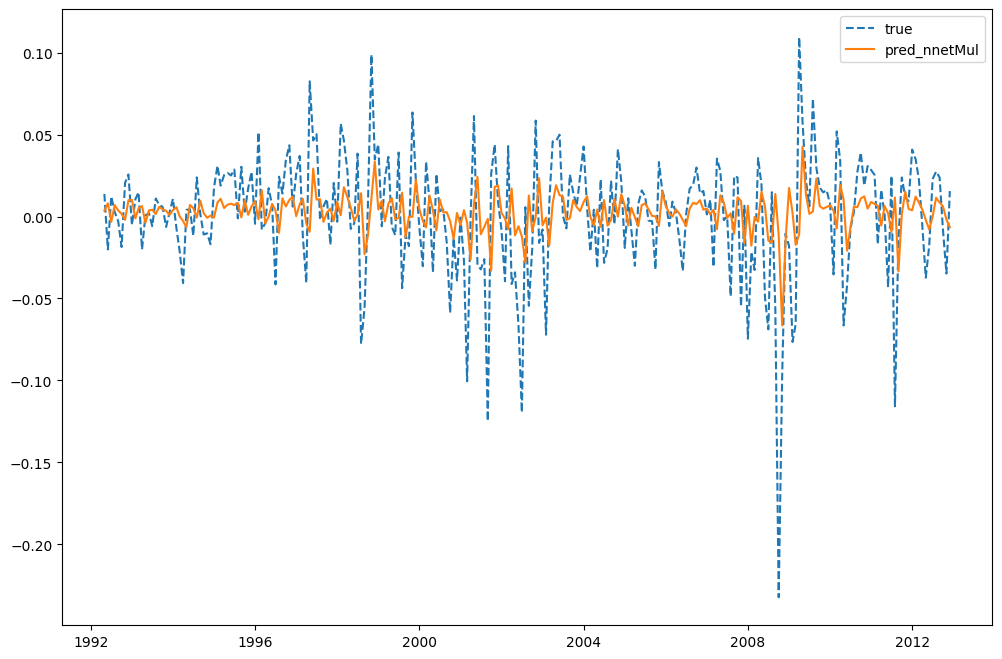

In [ ]:
# Plot the results of nnet1
plt.figure(figsize=(12, 8))
plt.plot(df_res['true'], label='true', linestyle='--')
plt.plot(df_res['pred_nnetMul'], label='pred_nnetMul')
plt.legend()
plt.show()

they dont react well to the volatility spikes. 

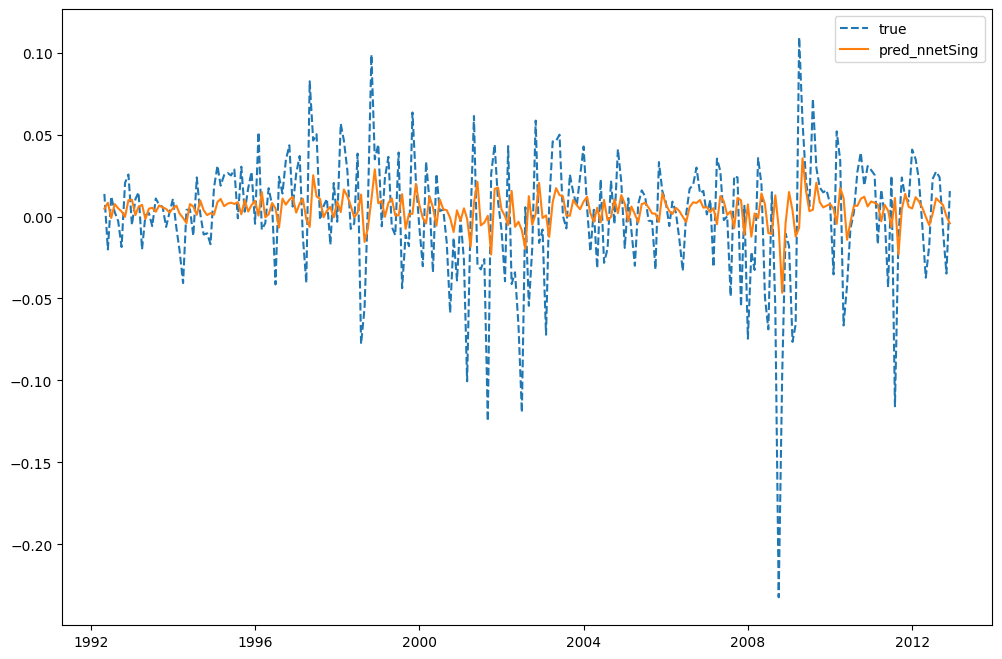

In [ ]:
# Plot the results of nnet2
plt.figure(figsize=(12, 8))
plt.plot(df_res['true'], label='true', linestyle='--')
plt.plot(df_res['pred_nnetSing'], label='pred_nnetSing')
plt.legend()
plt.show()

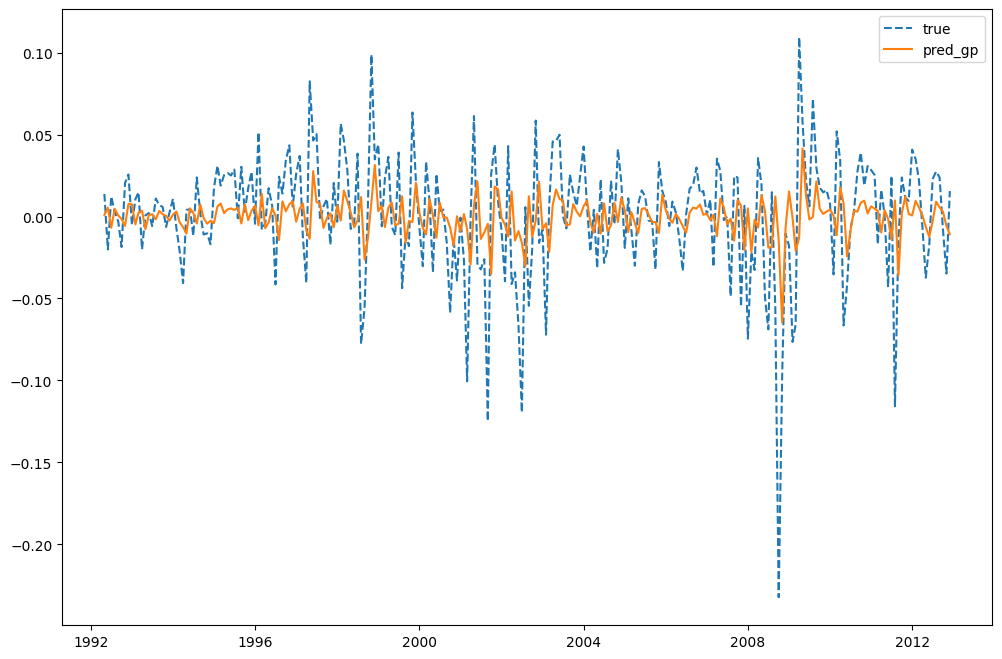

In [ ]:
# Plot the results of gp
plt.figure(figsize=(12, 8))
plt.plot(df_res['true'], label='true', linestyle='--')
plt.plot(df_res['pred_gp'], label='pred_gp')
plt.legend()
plt.show()

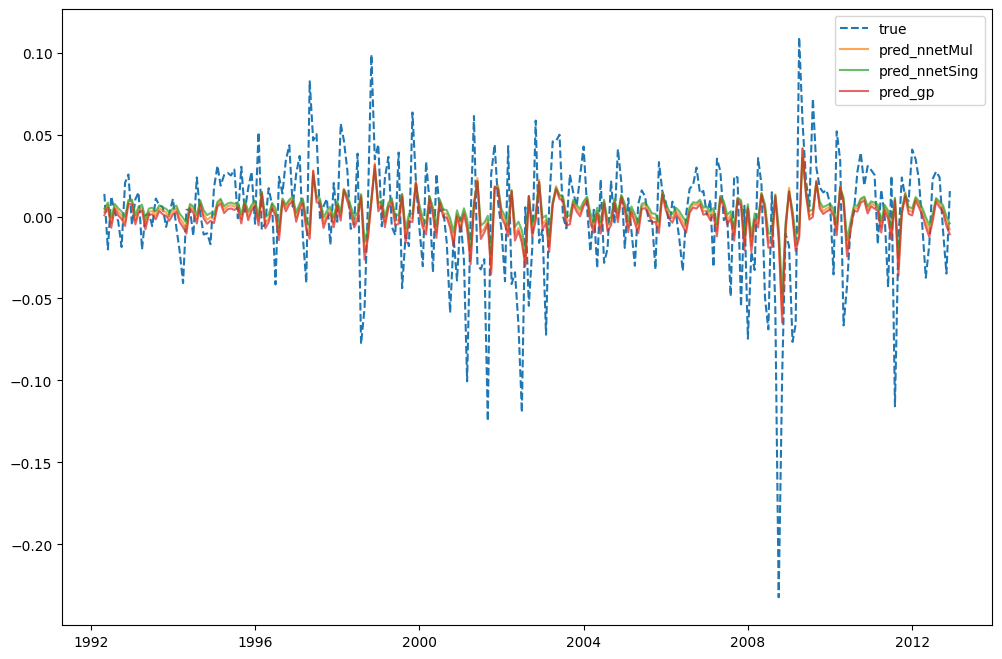

In [ ]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(df_res['true'], label='true', linestyle='--')
plt.plot(df_res['pred_nnetMul'], label='pred_nnetMul', alpha=0.7)
plt.plot(df_res['pred_nnetSing'], label='pred_nnetSing', alpha=0.7)
plt.plot(df_res['pred_gp'], label='pred_gp', alpha=0.7)
plt.legend()
plt.show()

##Model 4: LSTM with Tensorflow (Keras)
Official documentation. A quickstart guide:

https://www.tensorflow.org/tutorials/quickstart/beginner

LSTM help manual:
https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM

Some tutorials for Tensorflow/LSTM:
https://machinelearningmastery.com/time-series-prediction-lstm-recurrent-neural-networks-python-keras/

In [ ]:
# Reshape the features for LSTM input
# LSTM expects input in the shape (samples, timesteps, features)
timesteps = 10  # Number of past time steps to consider, so target is 11
features = training.shape[1] - 1  # Number of features (excluding target)
X_train = []
y_train = []
for i in range(timesteps, training.shape[0]):
    X_train.append(training.iloc[i - timesteps:i, :-1].values)  # Exclude target column
    y_train.append(training.iloc[i, -1])  # Target column
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], features))

# Define the LSTM model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], features)))
model.add(LSTM(units=50))
model.add(Dense(1))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


we can always add a validation set to check if we're overfitting

###Explanation of definition of LSTM:
- model = Sequential() : This initializes a linear stack of layers (the common arquitecture of neural networks)

- model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], features))): This adds a hidden layer with 50 units (cells) of LSTM (recurrent modules);  
return_sequences=True: because this is the first LSTM layer in a stacked LSTM architecture and want that the output of this layer to be a sequence, which will be fed as input to the next LSTM layer.
input_shape=(X_train.shape[1], features): This specifies the shape of the input data that the LSTM layer will receive. X_train.shape[1] represents the number of time steps in the input sequence, and features represents the number of features at each time step. (This number of time steps sets the length of the unrolled recurrence)

- model.add(LSTM(units=50)): This  adds a second LSTM layer to the model. Notice that return_sequences is not set to True here. This is because this is the last LSTM layer, and we want its output to be a single vector (not a sequence) that can be fed to the dense layer.

- model.add(Dense(1)): This line adds a dense layer (also known as a fully connected layer) to the model. It has a single unit, which will output the final prediction of the model (e.g., the next value in the time series).


Check the manual page for other parameters to set for LSTM:
https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM




In [ ]:
# Compile the model
model.compile(loss='mean_squared_error', optimizer='adam')

# Train the model
model.fit(X_train, y_train, epochs=100, batch_size=32)

In [ ]:
# Prepare testing data
X_test = []
for i in range(timesteps, testing.shape[0]):
    X_test.append(testing.iloc[i - timesteps:i, :-1].values)  # Exclude target column
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], features))

# Make predictions
pred_lstm = model.predict(X_test)

# Evaluate the model
print(tabulate([['LSTM', pcorrect(pred_lstm.flatten(), testing.iloc[timesteps:, -1])]],  # Target column
              headers=['Model', '% outperform mean']))


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
Model      % outperform mean
-------  -------------------
LSTM                 75.8209


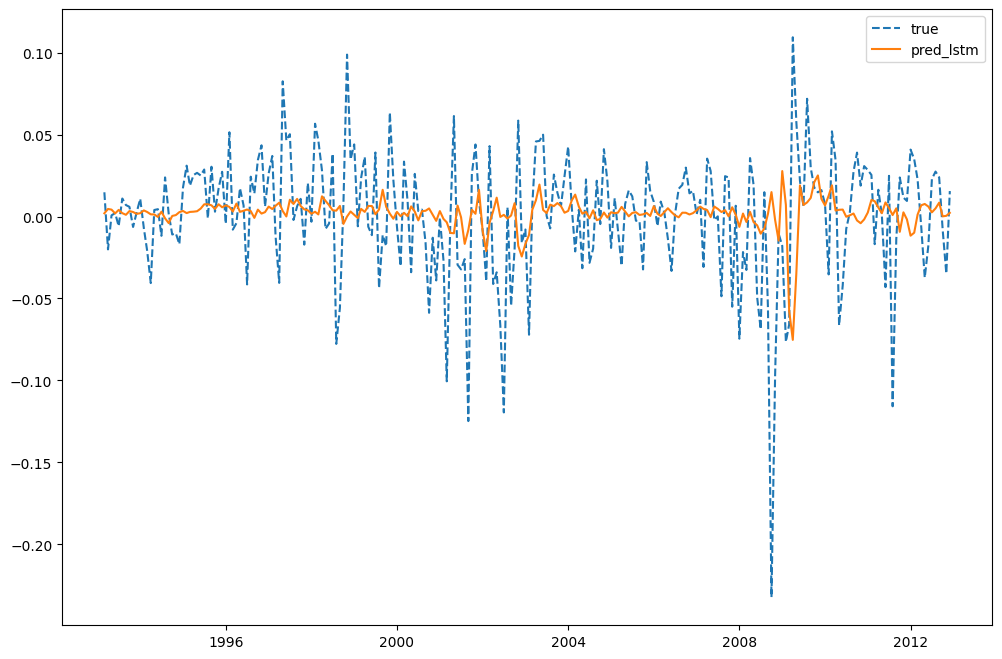

In [ ]:
# Plot the results
plt.figure(figsize=(12, 8))
plt.plot(testing.iloc[timesteps:, -1].index, testing.iloc[timesteps:, -1], label='true', linestyle='--')  # Target column with index
plt.plot(testing.iloc[timesteps:, -1].index, pred_lstm, label='pred_lstm') # Predictions with same index
plt.legend()
plt.show()